## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.heston import HestonModel
from src.models.sabr import SABRModel

from src.pricing.heston_pricer import heston_implied_volatility
from src.pricing.sabr_formula import hagan_implied_volatility

from src.calibration.optimizers import (
    calibrate_heston_surface,
    calibrate_sabr_smile,
)

## Parameters

In [2]:
spot = 100.0
rate = 0.03
dividend_yield = 0.0

strikes = np.array([80, 90, 100, 110, 120], dtype=float)
maturities = np.array([0.25, 0.50, 1.00, 2.00], dtype=float)

## Models

### Heston

In [3]:
true_heston = HestonModel(
    kappa=2.0,
    theta=0.04,
    sigma=0.30,
    rho=-0.70,
    v0=0.04,
)

In [4]:
market_surface = np.zeros((len(maturities), len(strikes)))

for i, maturity in enumerate(maturities):
    for j, strike in enumerate(strikes):
        market_surface[i, j] = heston_implied_volatility(
            spot=spot,
            strike=strike,
            maturity=maturity,
            rate=rate,
            model=true_heston,
            dividend_yield=dividend_yield,
        )

In [5]:
calibrated_heston = calibrate_heston_surface(
    strikes=strikes,
    maturities=maturities,
    market_vol_surface=market_surface,
    spot=spot,
    rate=rate,
    dividend_yield=dividend_yield,
    initial_guess=(1.5, 0.05, 0.25, -0.5, 0.05),
)

In [6]:
heston_surface = np.zeros_like(market_surface)

for i, maturity in enumerate(maturities):
    for j, strike in enumerate(strikes):
        heston_surface[i, j] = heston_implied_volatility(
            spot=spot,
            strike=strike,
            maturity=maturity,
            rate=rate,
            model=calibrated_heston,
            dividend_yield=dividend_yield,
        )

### SABR

In [7]:
beta = 0.5

sabr_models = {}
sabr_surface = np.zeros_like(market_surface)

for i, maturity in enumerate(maturities):
    sabr_model = calibrate_sabr_smile(
        strikes=strikes,
        market_vols=market_surface[i],
        forward=spot * np.exp((rate - dividend_yield) * maturity),
        maturity=maturity,
        beta=beta,
        initial_guess=(0.2, -0.2, 0.7),
    )

    sabr_models[maturity] = sabr_model

    forward = spot * np.exp((rate - dividend_yield) * maturity)

    for j, strike in enumerate(strikes):
        sabr_surface[i, j] = hagan_implied_volatility(
            forward=forward,
            strike=strike,
            maturity=maturity,
            model=sabr_model,
        )

## Metrics

In [8]:
def compute_metrics(model_surface, market_surface):
    residuals = model_surface - market_surface

    return {
        "RMSE": np.sqrt(np.mean(residuals**2)),
        "MAE": np.mean(np.abs(residuals)),
        "Max Error": np.max(np.abs(residuals)),
    }


metrics = pd.DataFrame({
    "Heston": compute_metrics(heston_surface, market_surface),
    "SABR": compute_metrics(sabr_surface, market_surface),
}).T

metrics

,RMSE,MAE,Max Error
Heston,0.000846,0.000668,0.001482
SABR,0.013851,0.006495,0.044616


## Plot

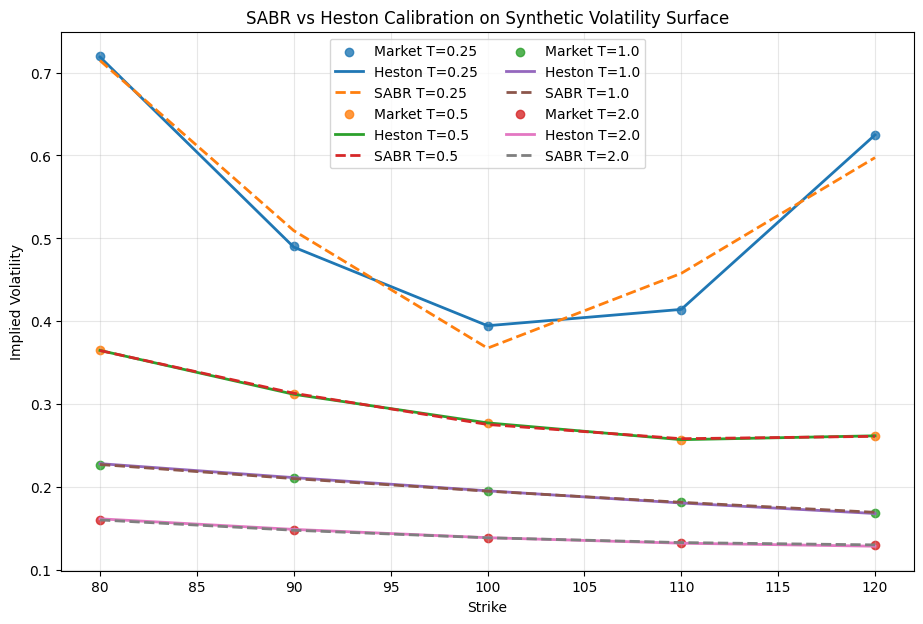

In [9]:
plt.figure(figsize=(11, 7))

for i, maturity in enumerate(maturities):
    plt.scatter(
        strikes,
        market_surface[i],
        label=f"Market T={maturity}",
        alpha=0.8,
    )

    plt.plot(
        strikes,
        heston_surface[i],
        linewidth=2,
        label=f"Heston T={maturity}",
    )

    plt.plot(
        strikes,
        sabr_surface[i],
        linestyle="--",
        linewidth=2,
        label=f"SABR T={maturity}",
    )

plt.title("SABR vs Heston Calibration on Synthetic Volatility Surface")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
heston_residuals = heston_surface - market_surface
sabr_residuals = sabr_surface - market_surface

residual_comparison = pd.DataFrame({
    "Maturity": np.repeat(maturities, len(strikes)),
    "Strike": np.tile(strikes, len(maturities)),
    "Heston residual": heston_residuals.flatten(),
    "SABR residual": sabr_residuals.flatten(),
})

residual_comparison

,Maturity,Strike,Heston residual,SABR residual
0,0.25,80.0,-0.000998,-0.005246
1,0.25,90.0,-0.001420,0.018477
2,0.25,100.0,-0.000167,-0.027222
3,0.25,110.0,0.001154,0.044616
4,0.25,120.0,0.000392,-0.027002
5,0.50,80.0,-0.000141,-0.000252
6,0.50,90.0,0.000061,0.001314
7,0.50,100.0,0.000159,-0.001755
8,0.50,110.0,0.000126,0.001288
9,0.50,120.0,0.000246,-0.000392


## Conclusion

This notebook compares Heston and SABR on the same synthetic volatility surface.

Heston is calibrated globally across all strikes and maturities, while SABR is calibrated independently smile-by-smile for each maturity. This highlights an important modelling difference:

- Heston provides a dynamic stochastic volatility model with one parameter set across the whole surface.
- SABR provides a flexible local smile fit, usually calibrated separately by maturity.

On a surface generated by Heston, the Heston model is expected to recover the surface more consistently. SABR can still fit individual smiles accurately, but its parameters vary across maturities because it does not enforce a single global dynamics across the whole surface.